Epoch 1: loss = 2.2070
Epoch 2: loss = 1.9179
Epoch 3: loss = 1.6569
Epoch 4: loss = 1.4788
Epoch 5: loss = 1.4208
Epoch 6: loss = 1.3682
Epoch 7: loss = 1.3847
Epoch 8: loss = 1.3556
Epoch 9: loss = 1.2995
Epoch 10: loss = 1.3610
Epoch 11: loss = 1.3525
Epoch 12: loss = 1.3229
Epoch 13: loss = 1.3534
Epoch 14: loss = 1.3089
Epoch 15: loss = 1.2711
Epoch 16: loss = 1.3330
Epoch 17: loss = 1.2973
Epoch 18: loss = 1.2909
Epoch 19: loss = 1.3419
Epoch 20: loss = 1.2806


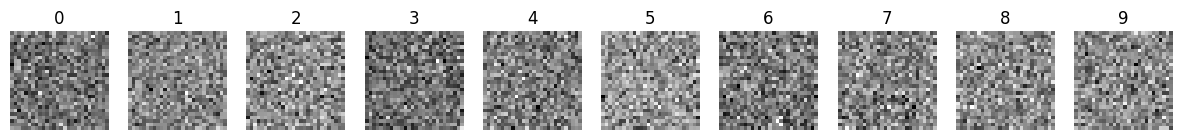

In [ ]:
import torch 
from torch import nn, Tensor 
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from typing import override 
import matplotlib.pyplot as plt 
from enum import Enum

from pprint import pprint

class Mode(Enum):
    CNN = 1
    BasicTransformer = 2

    def to_string(self):
        return self.name

MODE = Mode.BasicTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"


# ================================================================
# Version 1: CNN Architecture
# ================================================================
class FlowMatching(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.digit_embedding = nn.Embedding(10, 64)
        self.time_embedding = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )
        self.net = nn.Sequential(
            nn.Conv2d(1 + 64 + 64, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 1, 3, padding=1),
        )



    @override 
    def forward(self, x, t, digit):

        B, _, H, W = x.shape 
        
        digit_emb = self.digit_embedding(digit)

        # Embed digit: [B, 64] -> [B, 64, H, W]
        digit_emb = digit_emb[:, :, None, None]
        digit_emb = digit_emb.expand(-1, -1, H, W)

        # Embed time: [B] -> [B, 1] -> [B, 64]
        time_emb = self.time_embedding(t[:, None])

        # [B, 64] -> [B, 64, H, W]
        time_emb = time_emb[:, :, None, None].expand(-1, -1, H, W)

        # concatenate everything 
        x = torch.cat([x, digit_emb, time_emb], dim=1)

        return self.net(x)


# ================================================================
# version 2: transformer architecture
# ================================================================
class FlowMatching_with_Transformer(nn.Module):
    def __init__(self):
        super().__init__() 

        self.embedding_dim=32

        self.digit_embedding = nn.Embedding(
            num_embeddings=10,
            embedding_dim=self.embedding_dim
        )

        self.time_embedding = nn.Sequential(
            nn.Linear(1, self.embedding_dim),
            nn.SiLU(),
            nn.Linear(self.embedding_dim, self.embedding_dim),
        )

        self.patch_embedding = nn.Conv2d(
            in_channels=1,
            out_channels=self.embedding_dim,
            kernel_size=4,
            stride=4,
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, 49, self.embedding_dim)
        )

        self.num_layers = 4
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=self.embedding_dim,
                nhead=4,
                dim_feedforward=128,
                batch_first=True
            )
            for _ in range(self.num_layers)
        ])

        self.output_proj = nn.Linear(
            self.embedding_dim, 
            4 * 4,
        )



    @override
    def forward(self, x, t, digit):

        digit_emb = self.digit_embedding(digit)
        digit_emb = digit_emb.unsqueeze(1)

        time_emb = self.time_embedding(t.unsqueeze(1)).unsqueeze(1)

        patch = self.patch_embedding(x)
        patch = patch.flatten(2)
        patch = patch.transpose(1, 2)

        image_tokens = patch + self.pos_embedding

        x = torch.cat([
            digit_emb, 
            time_emb,
            image_tokens,
            ], dim=1
        )

        for layer in self.layers:
            x = layer(x)


        # remove digit and time tokens again 
        image_tokens = x[:, 2:, :]

        # convert each token back into a 4x4 patch 
        patches = self.output_proj(image_tokens)
        patches = patches.transpose(1, 2) # back to [B, 16, 49]

        # reconstruct the velocity image 
        velocity = F.fold(
            patches, 
            output_size=(28, 28),
            kernel_size=4,
            stride=4,
        ) # [B, 1, 28, 28]

        return velocity

# ================================================================
# Training
# ================================================================

def create_loader(training_size=1024, batch_size=128) -> DataLoader:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = datasets.MNIST(
        root="./data", 
        train=True,
        download=True,
        transform=transform,
    )

    indices = torch.randperm(len(dataset))[:training_size]
    dataset = Subset(dataset, indices)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
    )


def train(model, loader, training_epochs=20):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(training_epochs):

        total_loss = 0 

        for x1, digit in loader:

            x1 = x1.to(device)
            digit = digit.to(device)

            B = x1.shape[0]
            x0 = torch.randn_like(x1) # gausssian source distribution

            t = torch.rand(B, device=device)

            t_img = t[:, None, None, None]
            xt = ((1 - t_img) * x0 + t_img * x1)

            target_velocity = x1 - x0
            predicted_velocity = model(xt, t, digit)

            loss = F.mse_loss(
                predicted_velocity,
                target_velocity,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step() 

            total_loss += loss.item() 

        print(
            f"Epoch {epoch + 1}: "
            f"loss = {total_loss / len(loader):.4f}"
        )

@torch.no_grad()
def generate(model, digits, steps=10):

    model.eval() 

    B = len(digits)
    x = torch.randn(
        B, 1, 28, 28,
        device=device,
    )

    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full(
            (B,),
            i / steps,
            device=device
        ) # Creates tensor of batch_size with the current time step

        velocity = model(
            x,
            t,
            digits,
        )

        x += dt * velocity

    return x 

def show_all_digits(model):
    digits = torch.arange(10, device=device)
    samples = generate(
        model, digits, steps=50
    )

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))

    for i, ax in enumerate(axes):
        ax.imshow(
            samples[i, 0].cpu(),
            cmap="gray",
        )

        ax.set_title(str(i))
        ax.axis("off")
    plt.show()

def save_model(model) -> None:
    filename = f"{MODE.to_string()}.pt"
    model.to("cpu")
    model.eval()
    torch.save(model.state_dict(), filename)

def load_model(model):
    filename = f"{MODE.to_string()}.pt"
    model.load_state_dict(torch.load(filename, map_location=device))
    return model


def main():

    match MODE:
        case Mode.CNN:
            model = FlowMatching().to(device)
        case Mode.BasicTransformer:
            model = FlowMatching_with_Transformer().to(device)
    

    loader = create_loader(training_size=10, batch_size=10)
    train(model, loader)
    show_all_digits(model)

    save_model(model)

    # model = load_model(model)
    # show_all_digits(model)
    
    return model


model = main()

In [56]:
print(model.layers[0]._modules.keys())

obj = model.layers[0]._modules['norm1']._parameters


print(type(obj))
pprint(obj)


odict_keys(['self_attn', 'linear1', 'dropout', 'linear2', 'norm1', 'norm2', 'dropout1', 'dropout2'])
<class 'collections.OrderedDict'>
OrderedDict([('weight',
              Parameter containing:
tensor([1.0103, 1.0090, 0.9878, 1.0104, 1.0126, 0.9935, 0.9885, 0.9927, 1.0099,
        0.9893, 0.9895, 0.9914, 0.9969, 1.0154, 1.0092, 0.9903, 1.0132, 0.9924,
        1.0006, 1.0097, 1.0004, 0.9891, 1.0115, 0.9979, 0.9941, 0.9860, 1.0000,
        0.9938, 0.9995, 1.0139, 1.0008, 1.0111, 0.9999, 1.0059, 1.0081, 0.9956,
        1.0025, 0.9879, 0.9881, 0.9887, 1.0045, 0.9933, 0.9949, 1.0087, 0.9886,
        0.9947, 1.0066, 1.0052, 1.0100, 1.0120, 0.9901, 0.9883, 0.9926, 1.0018,
        0.9903, 0.9923, 1.0070, 0.9914, 1.0088, 0.9886, 0.9962, 1.0070, 0.9970,
        0.9900], requires_grad=True)),
             ('bias',
              Parameter containing:
tensor([-0.0031,  0.0075, -0.0021, -0.0091, -0.0080, -0.0092, -0.0109, -0.0078,
         0.0112,  0.0084,  0.0088, -0.0103,  0.0112, -0.0086, -0.008

In [15]:
model.layers[0]._named_members()

TypeError: Module._named_members() missing 1 required positional argument: 'get_members_fn'